# 05 - Train Stamp Forgery Classifier

This notebook trains a binary image classifier to distinguish **genuine wet-ink stamps (class 0)** from **digitally forged stamps (class 1)** using transfer learning with ResNet50.

**Input:** `outputs/roi_dataset_v3/` - 224×224 stamp ROI images from notebook 04  
**Output:** `outputs/models/stamp_resnet50_best.keras` and `stamp_resnet50_final.keras`

---
## Training Strategy (Two-Phase)

**Phase 1 - Feature Adaptation (frozen base)**  
The ResNet50 convolutional base is frozen. Only the custom classification head is trained at learning rate 1e-4 for up to 25 epochs. This teaches the head to interpret ResNet50's ImageNet features.

**Phase 2 - Fine-tuning (top 30 layers unfrozen)**  
The top 30 layers of ResNet50 are unfrozen and trained at a very low learning rate (1e-5) for up to 15 epochs. This adapts the high-level feature detectors to the specific microscopic textures of wet ink vs digital halftone patterns.

---
## Contents
1. Imports
2. Configuration
3. Build image path DataFrame
4. Stratified train / val / test split (70 / 15 / 15)
5. Function: `load_and_preprocess_image`
6. Function: `create_dataset` - tf.data pipeline
7. Data augmentation layer
8. Build ResNet50 model
9. Compute class weights
10. Phase 1 training
11. Plot training curves
12. Phase 2 - fine-tuning
13. Evaluate on test set
14. Classification report
15. Confusion matrix
16. Save final model


## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Configuration

| Variable | Value | Description |
|---|---|---|
| `ROI_DATASET_ROOT` | `../outputs/roi_dataset_v3/` | Input ROI images |
| `MODEL_OUTPUT_DIR` | `../outputs/models/` | Where trained models are saved |
| `IMG_SIZE` | 224 | Input image dimensions (px) |
| `BATCH_SIZE` | 16 | Batch size for training |
| `SEED` | 42 | Random seed for reproducibility |


In [2]:
ROI_DATASET_ROOT = Path("../outputs/roi_dataset_v3")

GENUINE_DIR = ROI_DATASET_ROOT / "genuine"
FORGED_DIR = ROI_DATASET_ROOT / "forged"

MODEL_OUTPUT_DIR = Path("../outputs/models")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

## 3. Build Image Path DataFrame

Scans `genuine/` and `forged/` output folders and builds a DataFrame with columns `image_path`, `label` (0/1), and `class_name`. This is the master record used for splitting and dataset creation.


In [3]:
records = []

for path in GENUINE_DIR.rglob("*.png"):
    records.append({
        "image_path": str(path),
        "label": 0,
        "class_name": "genuine"
    })

for path in FORGED_DIR.rglob("*.png"):
    records.append({
        "image_path": str(path),
        "label": 1,
        "class_name": "forged"
    })

df = pd.DataFrame(records)

print("Total clean ROI images:", len(df))
print(df["class_name"].value_counts())

df.head()

Total clean ROI images: 458
class_name
genuine    313
forged     145
Name: count, dtype: int64


,image_path,label,class_name
0,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
1,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
2,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
3,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine
4,..\outputs\roi_dataset_v3\genuine\Gen_A_300dpi...,0,genuine


## 4. Stratified Train / Val / Test Split

Splits the dataset into three subsets while preserving class proportions in each:

| Split | Fraction | Purpose |
|---|---|---|
| Train | 70% | Model training |
| Validation | 15% | Hyperparameter tuning and early stopping |
| Test | 15% | Final unbiased evaluation |

Uses `stratify=df["label"]` to ensure both classes appear in the correct ratio in all three splits.


In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts())

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train: 320
Validation: 69
Test: 69

Train distribution:
class_name
genuine    219
forged     101
Name: count, dtype: int64

Validation distribution:
class_name
genuine    47
forged     22
Name: count, dtype: int64

Test distribution:
class_name
genuine    47
forged     22
Name: count, dtype: int64


## 5. Function: `load_and_preprocess_image`

TensorFlow-native image loading function used inside the `tf.data` pipeline:
1. Reads the PNG file from disk
2. Decodes to a 3-channel RGB tensor
3. Resizes to 224×224
4. Applies `preprocess_input` (ResNet50-specific normalisation: zero-centres each channel using ImageNet mean/std)


In [5]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = preprocess_input(image)

    return image, label

## 6. Function: `create_dataset`

Builds an optimised `tf.data.Dataset` from a DataFrame:
- Converts paths and labels to tensors
- Optionally shuffles (training only)
- Maps `load_and_preprocess_image` with parallel calls (`AUTOTUNE`)
- Batches to `BATCH_SIZE`
- Prefetches one batch ahead to overlap I/O and GPU computation


In [6]:
def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

## 7. Data Augmentation Layer

An inline Keras augmentation layer applied **during training only** (not at inference):

| Augmentation | Range | Rationale |
|---|---|---|
| `RandomRotation` | ±8% (≈29°) | Stamps are applied at varying angles |
| `RandomZoom` | ±8% | Variation in scan distance/crop tightness |
| `RandomTranslation` | ±5% (x and y) | Stamp not always centred in ROI |
| `RandomContrast` | ±15% | Scanner brightness variation |

These augmentations are deliberately **conservative** to preserve the microscopic ink texture that the classifier depends on.


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
])

## 8. Build ResNet50 Model

### Architecture

```
Input (224×224×3)
    ↓
Data Augmentation (training only)
    ↓
ResNet50 base (ImageNet weights, frozen in Phase 1)
    ↓
GlobalAveragePooling2D
    ↓
Dropout(0.35)
    ↓
Dense(128, relu)
    ↓
Dropout(0.25)
    ↓
Dense(1, sigmoid)  →  P(forged)
```

### Why ResNet50?
ResNet50's residual connections allow it to learn both low-level texture features (relevant for detecting halftone dot patterns) and high-level structural features. With only ~300 training images, transfer learning from ImageNet is essential to avoid overfitting.

**Phase 1 compile settings:**  
- Optimizer: Adam, lr=1e-4  
- Loss: Binary cross-entropy  
- Metrics: accuracy, precision, recall


In [8]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 9. Compute Class Weights

Uses `sklearn.utils.class_weight.compute_class_weight` to calculate balanced class weights. If the ROI extraction in notebook 04 produced an unequal number of genuine and forged samples, these weights compensate during training so the model does not favour the majority class.


In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.730593607305936), 1: np.float64(1.5841584158415842)}


## 10. Phase 1 Training

Trains with the ResNet50 base **frozen** for up to **25 epochs**.

**Callbacks:**
- `EarlyStopping`: stops if `val_loss` does not improve for 6 epochs; restores best weights
- `ModelCheckpoint`: saves the best model (by `val_loss`) to `stamp_resnet50_best.keras`


In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_OUTPUT_DIR / "stamp_resnet50_best.keras"),
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.6156 - loss: 0.8747 - precision: 0.3922 - recall: 0.3960 - val_accuracy: 0.3043 - val_loss: 1.0686 - val_precision: 0.3030 - val_recall: 0.9091
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4656 - loss: 0.7927 - precision: 0.3098 - recall: 0.5644 - val_accuracy: 0.3623 - val_loss: 0.8314 - val_precision: 0.2609 - val_recall: 0.5455
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 940ms/step - accuracy: 0.5437 - loss: 0.7433 - precision: 0.3448 - recall: 0.4950 - val_accuracy: 0.3188 - val_loss: 0.9754 - val_precision: 0.3077 - val_recall: 0.9091
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 865ms/step - accuracy: 0.5219 - loss: 0.7320 - precision: 0.3452 - recall: 0.5743 - val_accuracy: 0.2899 - val_loss: 0.8846 - val_precision: 0.2632 - val_recall: 0.6818
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 885ms/step - accuracy: 0.5063 - loss: 0.7773 - precision: 0.3087 - recall: 0.4554 - val_accuracy: 0.2899 - val_loss: 0.9

## 11. Plot Training Curves

Plots accuracy and loss for both training and validation sets across Phase 1 epochs.

**What to look for:**
- Validation accuracy rising and stabilising → good generalisation
- Large gap between train and val accuracy → overfitting; reduce augmentation or increase dropout
- Val loss increasing while train loss decreases → overfitting; early stopping should handle this


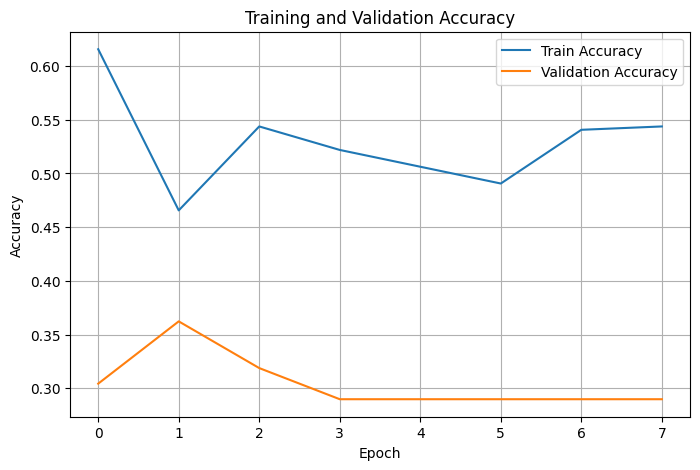

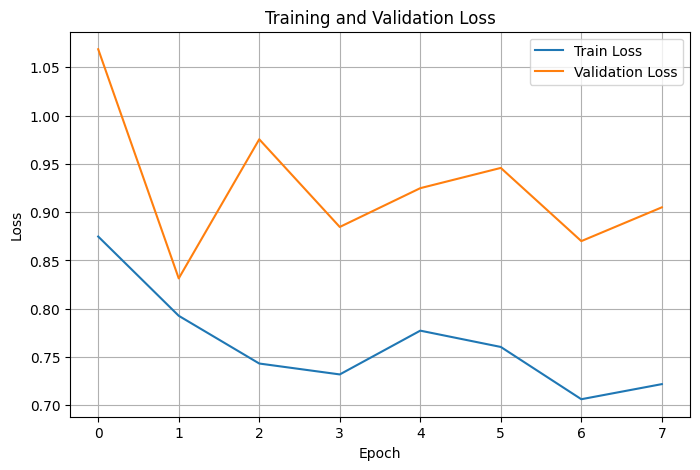

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 12. Phase 2 — Fine-Tuning

Unfreezes the **top 30 layers** of ResNet50 (the last residual blocks) and retrains at a much lower learning rate (1e-5).

```python
for layer in base_model.layers[:-30]:
    layer.trainable = False
```

The lower layers remain frozen because they detect generic low-level features (edges, textures) that are still useful. Only the high-level feature detectors are adapted to the stamp forgery domain.

**Why 1e-5?** A higher learning rate would destroy the pre-trained weights; a lower one would make no meaningful update.


In [ ]:
base_model.trainable = True

# Freeze lower layers, fine-tune only top part
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.4781 - loss: 0.7604 - precision: 0.3187 - recall: 0.5743 - val_accuracy: 0.4058 - val_loss: 0.8227 - val_precision: 0.2889 - val_recall: 0.5909
Epoch 2/15
16/20 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5233 - loss: 0.7048 - precision: 0.3202 - recall: 0.5517

## 13. Evaluate on Test Set

Runs the final model on the held-out test set and reports:
- Test loss
- Test accuracy
- Test precision
- Test recall
- Test F1-score (computed manually from precision and recall)

The test set was never used during training or validation, so these metrics reflect true generalisation performance.


In [ ]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-8)
print("Test F1-score:", f1_score)

## 14. Classification Report

Uses `sklearn.metrics.classification_report` to print per-class precision, recall, F1-score, and support for both `genuine` and `forged` classes. This is the primary evaluation table for the project report.


In [ ]:
y_true = test_df["label"].values

y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["genuine", "forged"]
))

## 15. Confusion Matrix

Visualises the 2×2 confusion matrix:

|  | Predicted genuine | Predicted forged |
|---|---|---|
| **Actual genuine** | True Negative | False Positive |
| **Actual forged** | False Negative | True Positive |

False negatives (forged stamps classified as genuine) are the highest-risk error in a document forensics context.


In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["genuine", "forged"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 16. Save Final Model

Saves the fully fine-tuned model to `outputs/models/stamp_resnet50_final.keras` for deployment or further evaluation.

Note: `stamp_resnet50_best.keras` (saved by ModelCheckpoint during training) may have slightly better validation loss; use that if test metrics are better on it.


In [ ]:
final_model_path = MODEL_OUTPUT_DIR / "stamp_resnet50_final.keras"

model.save(final_model_path)

print("Model saved to:")
print(final_model_path.resolve())